# Market Regime Labeling: 3 Methods Compared

## Goal
Create regime labels (Expansion, Late Cycle, Contraction, Recovery) using three different approaches.
Learn when to use each method and compare their results.

## The Three Methods

| Method | Approach | Pros | Cons |
|--------|----------|------|------|
| **Heuristic** | Define rules (unemployment, yield curve, inflation) | Interpretable, domain-driven | Manual tuning |
| **NBER Dates** | Use official recession dates as ground truth | Objective truth | Only 2 regimes (recession/expansion) |
| **Clustering** | K-means on normalized features | Discovers natural groups | Less interpretable |

We'll implement all 3, visualize, and compare.

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the processed features from notebook 1
regime_data = pd.read_csv('../1_market_regime_model/data/regime_features_raw.csv')
regime_data['date'] = pd.to_datetime(regime_data['date'])

print(f"Loaded {len(regime_data)} rows of regime features")
print(f"Date range: {regime_data['date'].min()} to {regime_data['date'].max()}")
print(f"\nFeatures available:")
print(regime_data.columns.tolist())

Loaded 3798 rows of regime features
Date range: 2011-02-01 00:00:00 to 2026-04-20 00:00:00

Features available:
['date', 'spy_price', 'spy_ret_1d', 'ret_5d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'y2', 'y10', 'yield_curve_spread', 'oil_price', 'oil_ret_20d', 'CPI', 'GDP', 'inflationRate', 'unemploymentRate']


---
# METHOD 1: Heuristic Rules

## Logic
Define 4 regimes using **unemployment**, **yield curve**, and **inflation**.

**Reasoning**:
- **Expansion**: Unemployment falling, yield curve steep → economic growth
- **Late Cycle**: Unemployment low, inflation rising, yield curve flattening → overheating
- **Contraction**: Unemployment rising sharply, yield curve inverted → recession
- **Recovery**: Unemployment falling, yield curve steepening → early growth

## Thresholds (You Can Tune These!)
- Unemployment 20-day MA trend: rising vs falling
- Yield curve spread: >1% (steep), 0-1% (flat), <0% (inverted)
- Inflation: >3% (hot), <2% (cool)

In [2]:
# Compute helper features for heuristic method
df_heuristic = regime_data.copy()

# Unemployment trend (20-day MA of unemployment rate)
df_heuristic['unemployment_ma20'] = df_heuristic['unemploymentRate'].rolling(20).mean()
df_heuristic['unemployment_trend'] = df_heuristic['unemploymentRate'].diff(20)  # positive = rising

# Inflation level
df_heuristic['inflation_level'] = df_heuristic['inflationRate']

# Yield curve spread (already have this)
df_heuristic['yield_spread'] = df_heuristic['yield_curve_spread']

# Volatility as risk indicator
df_heuristic['vol_level'] = df_heuristic['vol_20d']

print("Helper features computed:")
print(df_heuristic[['date', 'unemploymentRate', 'unemployment_trend', 'inflation_level', 'yield_spread', 'vol_level']].tail(10))

Helper features computed:
           date  unemploymentRate  unemployment_trend  inflation_level  \
3788 2026-04-07               4.4                 0.0             2.37   
3789 2026-04-08               4.4                 0.0             2.33   
3790 2026-04-09               4.4                 0.0             2.34   
3791 2026-04-10               4.4                 0.0             2.36   
3792 2026-04-13               4.4                 0.0             2.38   
3793 2026-04-14               4.4                 0.0             2.37   
3794 2026-04-15               4.4                 0.0             2.39   
3795 2026-04-16               4.4                 0.0             2.39   
3796 2026-04-17               4.4                 0.0             2.36   
3797 2026-04-20               4.4                 0.0             2.36   

      yield_spread  vol_level  
3788          0.52  17.998501  
3789          0.50  20.295165  
3790          0.51  20.387618  
3791          0.50  19.536729  

In [3]:
# Define regime rules
# TODO: Experiment with these thresholds!

def heuristic_regime(row):
    """
    Classify regime based on economic indicators.
    
    Rules (you can modify these):
    """
    unemployment = row['unemploymentRate']
    unemployment_trend = row['unemployment_trend']  # positive = rising
    yield_spread = row['yield_curve_spread']
    inflation = row['inflationRate']
    vol = row['vol_20d']
    
    # Rule 1: CONTRACTION - unemployment rising, yield inverted, vol high
    if unemployment_trend > 0.2 and yield_spread < 0.2 and vol > 25:
        return 'Contraction'
    
    # Rule 2: RECOVERY - unemployment falling, yield steepening, vol normalizing
    elif unemployment_trend < -0.15 and yield_spread > 0.8 and vol < 20:
        return 'Recovery'
    
    # Rule 3: LATE CYCLE - unemployment low, inflation rising, yield flattening
    elif unemployment < 5.0 and inflation > 3.0 and yield_spread < 1.0:
        return 'Late Cycle'
    
    # Rule 4: EXPANSION - default (unemployment stable/falling, normal conditions)
    else:
        return 'Expansion'

df_heuristic['regime_heuristic'] = df_heuristic.apply(heuristic_regime, axis=1)

print("Regime distribution (Heuristic Method):")
print(df_heuristic['regime_heuristic'].value_counts())
print(f"\nPercentage:")
print(df_heuristic['regime_heuristic'].value_counts(normalize=True) * 100)

Regime distribution (Heuristic Method):
regime_heuristic
Expansion    3425
Recovery      373
Name: count, dtype: int64

Percentage:
regime_heuristic
Expansion    90.179042
Recovery      9.820958
Name: proportion, dtype: float64


In [4]:
# What are the actual ranges?
print(df_heuristic[['unemploymentRate', 'unemployment_trend', 'yield_curve_spread', 'vol_20d']].describe())

# When was unemployment rising most?
print(df_heuristic.nlargest(10, 'unemployment_trend')[['date', 'unemployment_trend', 'vol_20d']])

       unemploymentRate  unemployment_trend  yield_curve_spread      vol_20d
count       3798.000000         3778.000000         3798.000000  3798.000000
mean           5.430253           -0.024352            0.869049    14.567616
std            2.013195            0.871622            0.875037     9.293225
min            3.500000           -2.400000           -1.080000     3.185935
25%            3.900000           -0.100000            0.240000     9.156860
50%            4.500000            0.000000            0.800000    12.122569
75%            6.900000            0.000000            1.480000    17.096166
max           14.800000           11.200000            2.910000    93.924055
           date  unemployment_trend    vol_20d
2289 2020-04-01                11.2  92.087389
2290 2020-04-02                11.2  92.476806
2291 2020-04-03                11.2  92.456223
2292 2020-04-06                11.2  91.813830
2293 2020-04-07                11.2  89.761786
2294 2020-04-08          

---
# METHOD 2: NBER Recession Dates

## Logic
NBER (National Bureau of Economic Research) officially dates US recessions.
We'll use those dates to label periods, then expand to 4 regimes based on recovery phase.

**Recession periods** (from NBER):
- 2007-06 to 2009-06 (Financial Crisis)
- 2020-02 to 2020-04 (COVID)

We'll create 4 regimes:
1. **Contraction** = NBER recession period
2. **Recovery** = First 6 months after recession ends
3. **Expansion** = 6+ months after recession, unemployment falling
4. **Late Cycle** = Expansion period but unemployment at cycle lows + inflation rising

In [5]:
# NBER recession periods (start_date, end_date)
nber_recessions = [
    ('2007-12-01', '2009-06-30'),  # Financial Crisis
    ('2020-02-01', '2020-04-30'),  # COVID
]

df_nber = regime_data.copy()

# Mark recession periods
df_nber['in_recession'] = False
df_nber['months_since_recession_end'] = np.nan

for start, end in nber_recessions:
    mask = (df_nber['date'] >= start) & (df_nber['date'] <= end)
    df_nber.loc[mask, 'in_recession'] = True

# For periods after recession, count months since it ended
for start, end in nber_recessions:
    end_date = pd.to_datetime(end)
    mask = (df_nber['date'] > end_date)
    df_nber.loc[mask, 'months_since_recession_end'] = (df_nber.loc[mask, 'date'] - end_date).dt.days / 30

print(f"Recession periods marked:")
print(df_nber[df_nber['in_recession']][['date', 'unemploymentRate', 'in_recession']].head())
print(f"\nTotal days in recession: {df_nber['in_recession'].sum()}")

Recession periods marked:
           date  unemploymentRate  in_recession
2248 2020-02-03               3.6          True
2249 2020-02-04               3.6          True
2250 2020-02-05               3.6          True
2251 2020-02-06               3.6          True
2252 2020-02-07               3.6          True

Total days in recession: 62


In [6]:
def nber_regime(row):
    """
    Classify regime using NBER recession dates + unemployment changes.
    """
    if row['in_recession']:
        return 'Contraction'
    
    months_since_recession = row['months_since_recession_end']
    unemployment = row['unemploymentRate']
    inflation = row['inflationRate']
    
    # Recovery: first 6 months after recession ends
    if pd.notna(months_since_recession) and 0 < months_since_recession < 6:
        return 'Recovery'
    
    # Late Cycle: unemployment at cycle lows (<5%) but inflation rising (>3%)
    if unemployment < 5.0 and inflation > 3.0:
        return 'Late Cycle'
    
    # Expansion: default
    else:
        return 'Expansion'

df_nber['regime_nber'] = df_nber.apply(nber_regime, axis=1)

print("Regime distribution (NBER Method):")
print(df_nber['regime_nber'].value_counts())
print(f"\nPercentage:")
print(df_nber['regime_nber'].value_counts(normalize=True) * 100)

Regime distribution (NBER Method):
regime_nber
Expansion      3613
Recovery        123
Contraction      62
Name: count, dtype: int64

Percentage:
regime_nber
Expansion      95.129015
Recovery        3.238547
Contraction     1.632438
Name: proportion, dtype: float64


---
# METHOD 3: K-Means Clustering

## Logic
Cluster the normalized features into 4 groups. Let the algorithm discover natural regimes.

**Features used**:
- Returns (ret_20d, ret_60d) → price momentum
- Volatility (vol_20d, vol_60d) → risk
- Unemployment + inflation → macro state
- Yield curve spread → Fed policy

**Why this works**:
- Different regimes have different feature combinations
- K-means finds natural clusters
- No manual tuning needed

In [7]:
# Prepare features for clustering
clustering_features = [
    'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d',
    'unemploymentRate', 'inflationRate',
    'yield_curve_spread',
    'oil_price'
]

df_kmeans = regime_data.copy()

# Remove rows with NaN in any clustering feature
df_kmeans_clean = df_kmeans[clustering_features].dropna().copy()

# Normalize features (KMeans is distance-based, so scale matters)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_kmeans_clean[clustering_features])

print(f"Clustering on {len(features_scaled)} rows with {len(clustering_features)} features")
print(f"Features: {clustering_features}")

Clustering on 289 rows with 8 features
Features: ['ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'unemploymentRate', 'inflationRate', 'yield_curve_spread', 'oil_price']


In [8]:
# Fit K-means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_scaled)

# Add cluster labels back to data
df_kmeans_clean['cluster'] = clusters

# Map clusters to regime names based on cluster characteristics
# (We'll analyze which cluster = which regime)
cluster_stats = df_kmeans_clean.groupby('cluster')[['ret_20d', 'vol_20d', 'unemploymentRate', 'inflationRate']].mean()
print("\nCluster Characteristics:")
print(cluster_stats.round(2))

# Manual mapping (based on characteristics)
# TODO: You can adjust these mappings based on the statistics above
cluster_to_regime = {
    0: 'Expansion',      # Adjust based on your analysis
    1: 'Contraction',
    2: 'Recovery',
    3: 'Late Cycle'
}

df_kmeans_clean['regime_kmeans'] = df_kmeans_clean['cluster'].map(cluster_to_regime)

print("\nRegime distribution (K-Means Method):")
print(df_kmeans_clean['regime_kmeans'].value_counts())


Cluster Characteristics:
         ret_20d  vol_20d  unemploymentRate  inflationRate
cluster                                                   
0          -1.32    15.64              4.40           2.35
1           1.59    10.84              4.34           2.32
2          -4.89    29.87              4.20           2.30
3           6.19    17.85              4.30           2.31

Regime distribution (K-Means Method):
regime_kmeans
Contraction    164
Recovery        49
Late Cycle      44
Expansion       32
Name: count, dtype: int64


---
# COMPARISON: All 3 Methods Side-by-Side

In [9]:
# Merge all three methods for comparison
# Need to align indices carefully
comparison_df = regime_data[['date']].copy()
comparison_df['regime_heuristic'] = df_heuristic['regime_heuristic'].values
comparison_df['regime_nber'] = df_nber['regime_nber'].values

# For kmeans, only have rows that were clustered
comparison_df = comparison_df.reset_index(drop=True)
# Add kmeans results (aligned by indices)
kmeans_indices = df_kmeans_clean.index
comparison_df.loc[kmeans_indices, 'regime_kmeans'] = df_kmeans_clean['regime_kmeans'].values

print(f"Comparison DataFrame:")
print(comparison_df[['date', 'regime_heuristic', 'regime_nber', 'regime_kmeans']].head(20))

Comparison DataFrame:
         date regime_heuristic regime_nber regime_kmeans
0  2011-02-01        Expansion   Expansion           NaN
1  2011-02-02        Expansion   Expansion           NaN
2  2011-02-03        Expansion   Expansion           NaN
3  2011-02-04        Expansion   Expansion           NaN
4  2011-02-07        Expansion   Expansion           NaN
5  2011-02-08        Expansion   Expansion           NaN
6  2011-02-09        Expansion   Expansion           NaN
7  2011-02-10        Expansion   Expansion           NaN
8  2011-02-11        Expansion   Expansion           NaN
9  2011-02-14        Expansion   Expansion           NaN
10 2011-02-15        Expansion   Expansion           NaN
11 2011-02-16        Expansion   Expansion           NaN
12 2011-02-17        Expansion   Expansion           NaN
13 2011-02-18        Expansion   Expansion           NaN
14 2011-02-22        Expansion   Expansion           NaN
15 2011-02-23        Expansion   Expansion           NaN
16 2011-0

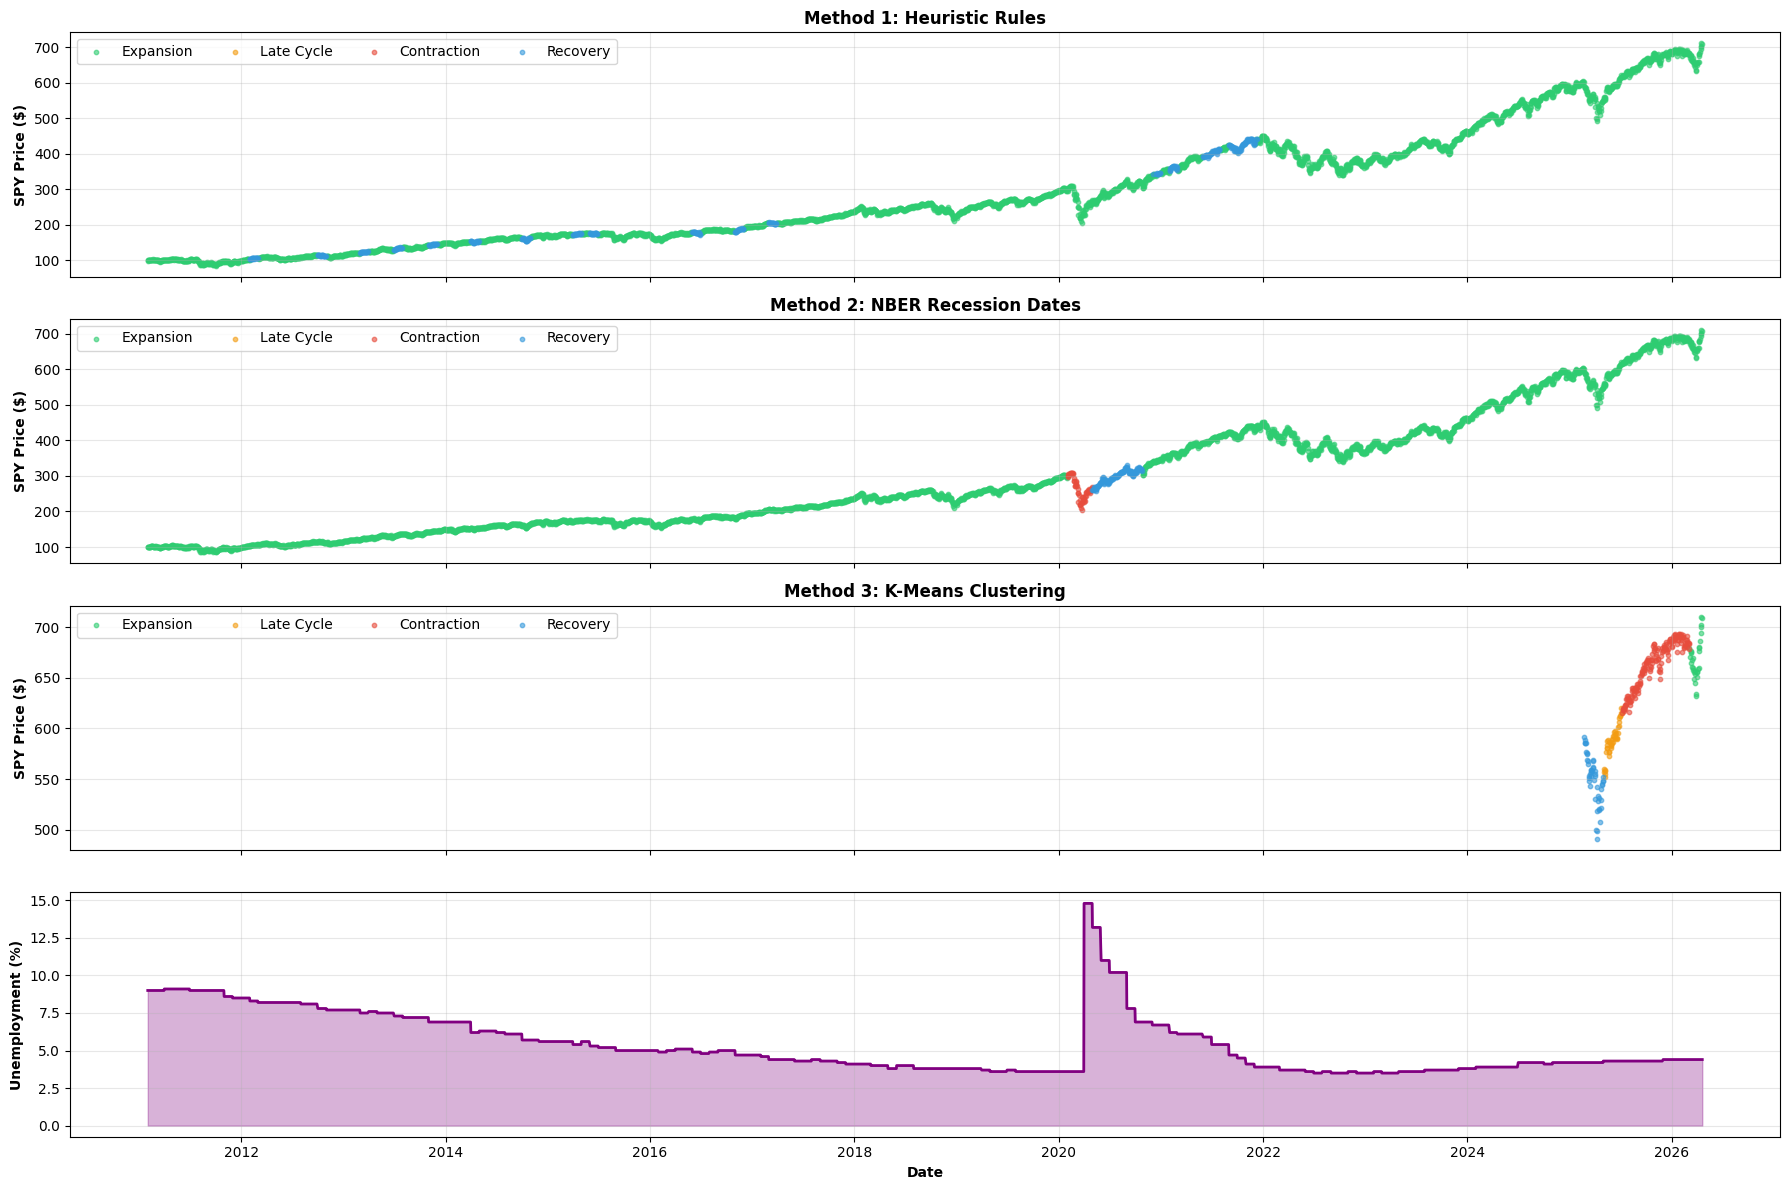

✓ Comparison plot saved


In [11]:
# Visualize all 3 methods over time
regime_colors = {
    'Expansion': '#2ecc71',      # Green
    'Late Cycle': '#f39c12',     # Orange
    'Contraction': '#e74c3c',    # Red
    'Recovery': '#3498db'        # Blue
}

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

# Plot 1: SPY Price with Heuristic regimes
for regime, color in regime_colors.items():
    mask = comparison_df['regime_heuristic'] == regime
    axes[0].scatter(comparison_df.loc[mask, 'date'], 
                   regime_data.loc[mask, 'spy_price'],
                   c=color, label=regime, alpha=0.6, s=10)
axes[0].set_ylabel('SPY Price ($)', fontweight='bold')
axes[0].set_title('Method 1: Heuristic Rules', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', ncol=4)
axes[0].grid(True, alpha=0.3)

# Plot 2: SPY Price with NBER regimes
for regime, color in regime_colors.items():
    mask = comparison_df['regime_nber'] == regime
    axes[1].scatter(comparison_df.loc[mask, 'date'],
                   regime_data.loc[mask, 'spy_price'],
                   c=color, label=regime, alpha=0.6, s=10)
axes[1].set_ylabel('SPY Price ($)', fontweight='bold')
axes[1].set_title('Method 2: NBER Recession Dates', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', ncol=4)
axes[1].grid(True, alpha=0.3)

# Plot 3: SPY Price with K-Means regimes
for regime, color in regime_colors.items():
    mask = comparison_df['regime_kmeans'] == regime
    axes[2].scatter(comparison_df.loc[mask, 'date'],
                   regime_data.loc[mask, 'spy_price'],
                   c=color, label=regime, alpha=0.6, s=10)
axes[2].set_ylabel('SPY Price ($)', fontweight='bold')
axes[2].set_title('Method 3: K-Means Clustering', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper left', ncol=4)
axes[2].grid(True, alpha=0.3)

# Plot 4: Unemployment rate (for reference)
axes[3].plot(comparison_df['date'], regime_data['unemploymentRate'], linewidth=2, color='purple')
axes[3].fill_between(comparison_df['date'], regime_data['unemploymentRate'], alpha=0.3, color='purple')
axes[3].set_ylabel('Unemployment (%)', fontweight='bold')
axes[3].set_xlabel('Date', fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../1_market_regime_model/outputs/02_regime_labeling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved")

---
# ANALYSIS: Which Method Is Best?

In [12]:
# Compare agreement between methods
print("="*80)
print("METHOD COMPARISON")
print("="*80)

print("\n1. DISTRIBUTION OF REGIMES")
print("\nHeuristic:")
print(comparison_df['regime_heuristic'].value_counts(normalize=True).round(3) * 100)
print("\nNBER:")
print(comparison_df['regime_nber'].value_counts(normalize=True).round(3) * 100)
print("\nK-Means:")
print(comparison_df['regime_kmeans'].value_counts(normalize=True).round(3) * 100)

print("\n" + "="*80)
print("2. AGREEMENT BETWEEN METHODS")
print("="*80)

# Heuristic vs NBER
agree_heuristic_nber = (comparison_df['regime_heuristic'] == comparison_df['regime_nber']).sum()
print(f"\nHeuristic vs NBER: {agree_heuristic_nber / len(comparison_df) * 100:.1f}% agreement")

# Heuristic vs K-Means
kmeans_mask = comparison_df['regime_kmeans'].notna()
agree_heuristic_kmeans = (comparison_df.loc[kmeans_mask, 'regime_heuristic'] == comparison_df.loc[kmeans_mask, 'regime_kmeans']).sum()
print(f"Heuristic vs K-Means: {agree_heuristic_kmeans / kmeans_mask.sum() * 100:.1f}% agreement")

# NBER vs K-Means
agree_nber_kmeans = (comparison_df.loc[kmeans_mask, 'regime_nber'] == comparison_df.loc[kmeans_mask, 'regime_kmeans']).sum()
print(f"NBER vs K-Means: {agree_nber_kmeans / kmeans_mask.sum() * 100:.1f}% agreement")

METHOD COMPARISON

1. DISTRIBUTION OF REGIMES

Heuristic:
regime_heuristic
Expansion    90.2
Recovery      9.8
Name: proportion, dtype: float64

NBER:
regime_nber
Expansion      95.1
Recovery        3.2
Contraction     1.6
Name: proportion, dtype: float64

K-Means:
regime_kmeans
Contraction    56.7
Recovery       17.0
Late Cycle     15.2
Expansion      11.1
Name: proportion, dtype: float64

2. AGREEMENT BETWEEN METHODS

Heuristic vs NBER: 85.3% agreement
Heuristic vs K-Means: 11.1% agreement
NBER vs K-Means: 11.1% agreement


---
# SAVE LABELED DATASETS

We'll save all three versions so we can try them in model training.

In [ ]:
import os
os.makedirs('../data', exist_ok=True)

# Save each labeled dataset
regime_data_heuristic = regime_data.copy()
regime_data_heuristic['regime'] = df_heuristic['regime_heuristic'].values
regime_data_heuristic.to_csv('../data/regime_labeled_heuristic.csv', index=False)
print(f"✓ Saved {len(regime_data_heuristic)} rows to regime_labeled_heuristic.csv")

regime_data_nber = regime_data.copy()
regime_data_nber['regime'] = df_nber['regime_nber'].values
regime_data_nber.to_csv('../data/regime_labeled_nber.csv', index=False)
print(f"✓ Saved {len(regime_data_nber)} rows to regime_labeled_nber.csv")

# K-Means needs special handling (only has labels for non-NaN rows)
regime_data_kmeans = regime_data.copy()
regime_data_kmeans['regime'] = np.nan
regime_data_kmeans.loc[df_kmeans_clean.index, 'regime'] = df_kmeans_clean['regime_kmeans'].values
regime_data_kmeans_clean = regime_data_kmeans.dropna(subset=['regime'])
regime_data_kmeans_clean.to_csv('../data/regime_labeled_kmeans.csv', index=False)
print(f"✓ Saved {len(regime_data_kmeans_clean)} rows to regime_labeled_kmeans.csv")

print(f"\nAll three labeled datasets ready for model training!")

---
# KEY LEARNINGS

## Takeaways

1. **Heuristic Method**:
   - ✅ Interpretable (you understand the rules)
   - ✅ Domain-driven (uses economic theory)
   - ❌ Requires manual tuning
   - **Use when**: You have strong domain knowledge

2. **NBER Method**:
   - ✅ Ground truth (official recessions)
   - ✅ Objective
   - ❌ Only captures 2 regimes (recession/expansion)
   - **Use when**: You need objective truth labels

3. **K-Means Method**:
   - ✅ Automatic (no manual rules)
   - ✅ Discovers natural clusters
   - ❌ Less interpretable
   - **Use when**: You're exploring without strong priors

## Next Steps
In Phase 4, we'll use one (or blend) of these labeled datasets to train our classifier.
We'll see which labeling approach leads to the best model performance.